# Fig Coverage By Century


In [ ]:
# === notebook config (auto-managed; edit values, not the tag) ===
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Database
DB_PATH = "../data/humans_clean.sqlite3"

# Figure style — minimal, Nature/Science publication standard
FIGSIZE = (8, 5)
DPI = 120
FONT_TITLE = 16
FONT_LABEL = 13
FONT_TICK = 11
FONT_LEGEND = 10

# Light, restrained palette (avoid AI-slop saturation)
COLOR_PRIMARY = "#2171b5"
COLOR_SECONDARY = "#b5542a"
COLOR_NEUTRAL = "#7f7f7f"
COLOR_LIGHT = "#d9d9d9"
COLOR_ACCENT = "#6a9e3a"
PALETTE = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT, COLOR_NEUTRAL, COLOR_LIGHT]

import matplotlib as _mpl
_mpl.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
    "axes.titlesize": FONT_TITLE,
    "axes.labelsize": FONT_LABEL,
    "xtick.labelsize": FONT_TICK,
    "ytick.labelsize": FONT_TICK,
    "legend.fontsize": FONT_LEGEND,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})


## Polity coverage by century

This notebook shows how many individuals in the database have been
successfully assigned to a historical polity (via the Cliopatria matching),
broken down by century. The y-axis uses a log scale.

### 1. Query polity-assigned individuals per century

Count distinct `wikidata_id` in `individuals_cliopatria` grouped by century.
Only centuries with at least 5 individuals are kept.

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

DB = DB_PATH

conn = sqlite3.connect(DB)
conn.execute('PRAGMA cache_size=-1000000')

query = """
    SELECT (impact_date / 100) * 100 AS century, COUNT(DISTINCT wikidata_id) AS cnt
    FROM individuals_cliopatria
    WHERE impact_date BETWEEN -3500 AND 2050
    GROUP BY century ORDER BY century
"""

df = pd.read_sql(query, conn)
conn.close()

df = df[(df['century'] >= -3500) & (df['century'] <= 2000) & (df['cnt'] >= 5)]
centuries = df['century'].tolist()
polity_counts = df['cnt'].tolist()

print(f'{len(centuries)} centuries, {sum(polity_counts):,} individuals assigned to a polity')
df


### 2. Figure

Bar chart with one bar per century. Log y-axis with plain number formatting.

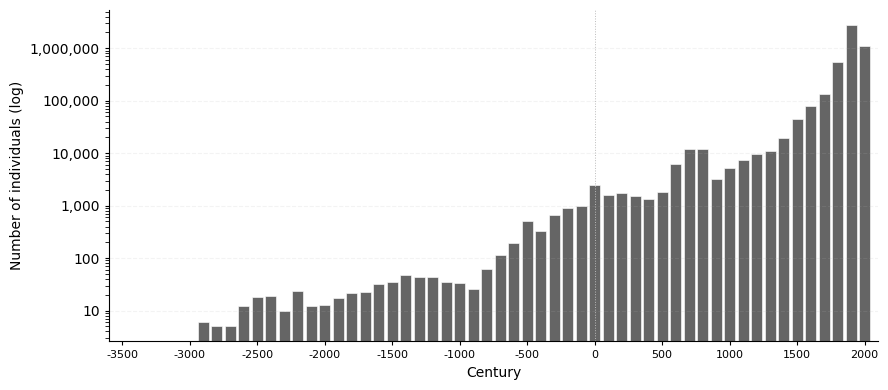

In [2]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(centuries, polity_counts, width=80, color='#4a4a4a', edgecolor='white',
       linewidth=0.5, alpha=0.85)

ax.set_yscale('log')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlabel('Century')
ax.set_ylabel('Number of individuals (log)')
ax.set_xlim(-3600, 2100)

xticks = list(range(-3500, 2500, 500))
ax.set_xticks(xticks)
ax.set_xticklabels([str(x) for x in xticks], fontsize=8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='both', length=3)
ax.grid(axis='y', alpha=0.15, linestyle='--')
ax.axvline(x=0, color='#bbbbbb', linestyle=':', linewidth=0.7)

plt.tight_layout()
plt.show()

### 3. Percentage of individuals with assigned polity per century

Compare total individuals (from `individuals_impact_date`) with those assigned to a polity.

In [3]:
conn = sqlite3.connect(DB)
conn.execute('PRAGMA cache_size=-1000000')

# Total individuals per century
query_total = """
    SELECT (CAST(impact_date AS INTEGER) / 100) * 100 AS century, 
           COUNT(DISTINCT wikidata_id) AS total_cnt
    FROM individuals_impact_date
    WHERE CAST(impact_date AS INTEGER) BETWEEN -3500 AND 2050
    GROUP BY century ORDER BY century
"""

# Individuals with polity per century
query_polity = """
    SELECT (impact_date / 100) * 100 AS century, 
           COUNT(DISTINCT wikidata_id) AS polity_cnt
    FROM individuals_cliopatria
    WHERE impact_date BETWEEN -3500 AND 2050
    GROUP BY century ORDER BY century
"""

df_total = pd.read_sql(query_total, conn)
df_polity = pd.read_sql(query_polity, conn)
conn.close()

# Merge and calculate percentage
df_pct = df_total.merge(df_polity, on='century', how='left')
df_pct['polity_cnt'] = df_pct['polity_cnt'].fillna(0)
df_pct['pct_with_polity'] = (df_pct['polity_cnt'] / df_pct['total_cnt']) * 100

# Filter centuries
df_pct = df_pct[(df_pct['century'] >= -3500) & (df_pct['century'] <= 2000) & (df_pct['total_cnt'] >= 5)]

print(f"Overall coverage: {df_pct['polity_cnt'].sum():,.0f} / {df_pct['total_cnt'].sum():,.0f} = {df_pct['polity_cnt'].sum() / df_pct['total_cnt'].sum() * 100:.1f}%")
df_pct

Overall coverage: 4,778,318 / 7,747,837 = 61.7%


,century,total_cnt,polity_cnt,pct_with_polity
1,-3400,10,0.0,0.000000
3,-3100,8,0.0,0.000000
4,-3000,15,2.0,13.333333
5,-2900,24,6.0,25.000000
6,-2800,20,5.0,25.000000
7,-2700,37,5.0,13.513514
8,-2600,56,12.0,21.428571
9,-2500,59,18.0,30.508475
10,-2400,104,19.0,18.269231
11,-2300,54,10.0,18.518519


/var/folders/lx/9b13r6ln63jb54_3xlf9b_380000gn/T/ipykernel_48766/2771027856.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower right', frameon=False)


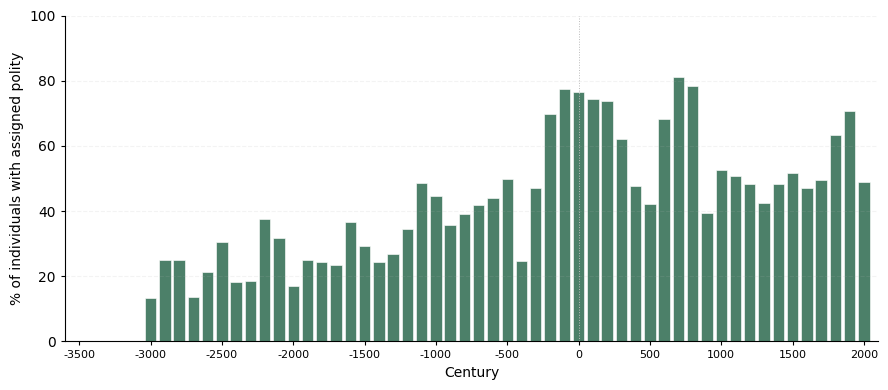

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(df_pct['century'], df_pct['pct_with_polity'], width=80, color='#2d6a4f', 
       edgecolor='white', linewidth=0.5, alpha=0.85)

ax.set_xlabel('Century')
ax.set_ylabel('% of individuals with assigned polity')
ax.set_xlim(-3600, 2100)
ax.set_ylim(0, 100)

xticks = list(range(-3500, 2500, 500))
ax.set_xticks(xticks)
ax.set_xticklabels([str(x) for x in xticks], fontsize=8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='both', length=3)
ax.grid(axis='y', alpha=0.15, linestyle='--')
ax.axvline(x=0, color='#bbbbbb', linestyle=':', linewidth=0.7)

# Add horizontal line at overall average
overall_pct = df_pct['polity_cnt'].sum() / df_pct['total_cnt'].sum() * 100
# ax.axhline(y=overall_pct, color='#d62828', linestyle='--', linewidth=1, alpha=0.7, 
#            label=f'Overall: {overall_pct:.1f}%')
ax.legend(loc='lower right', frameon=False)

plt.tight_layout()
plt.show()